In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import numpy as np

In [315]:
df = pd.read_feather("0_2GEMs_500gain_264.0sigmaT_590sigmaTransder_digitized.feather")

In [316]:
df['xmin'] = df['xdiff'].apply(lambda x: x.min())
df['ymin'] = df['ydiff'].apply(lambda x: x.min())
df['xmax'] = df['xdiff'].apply(lambda x: x.max())
df['ymax'] = df['ydiff'].apply(lambda x: x.max())

In [317]:
#GEM width is 3

df['qmax'] = df['qcam'].apply(lambda x: x.max())
df['isFiducial'] = 0
idx = df.query('xmin > -1.4 & xmax < 1.4 & ymin > -1.4 & ymax < 1.4 & qmax < 60000').index.to_numpy()
df['isFiducial'][idx] = 1

/tmp/ipykernel_384513/168722459.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['isFiducial'][idx] = 1


In [318]:
def compute_fsigpix_and_BB(i,thresh = 0.8):
    tmp = df.iloc[i]
    idx = np.where((tmp['ER_frac_cam'] > thresh) & (tmp['qcam']>100))[0]
    try:
        fsigpix = len(idx)/len(np.where((tmp['ER_frac_cam'] > 0) & (tmp['qcam']>100))[0])
    except:
        fsigpix = 0
    imNR = np.histogram2d(tmp['xcam'],tmp['ycam'],weights=tmp['qcam']*(1-tmp['ER_frac_cam']),bins=(512,288),range=((0,512),(0,288)))[0].T
    ys,xs = np.where(imNR > 100)
    NRxmin = xs.min()-5
    NRxmax = xs.max()+5
    NRymin = ys.min()-5
    NRymax = ys.max()+5    
    try:
        xmin = tmp['xcam'][idx].min()-1
        xmax = tmp['xcam'][idx].max()+1
        ymin = tmp['ycam'][idx].min()-1
        ymax = tmp['ycam'][idx].max()+1
    except:
        xmin = -1
        xmax = -1
        ymin = -1
        ymax = -1
    return fsigpix, xmin,xmax, ymin, ymax, NRxmin, NRxmax, NRymin, NRymax

In [319]:
fsigpix = []
xmin = []
xmax = []
ymin = []
ymax = []
NRxmin = []
NRxmax = []
NRymin = []
NRymax = []
for i in range(0,len(df)):
    f, xmi, xma, ymi, yma, NRxmi, NRxma, NRymi, NRyma = compute_fsigpix_and_BB(i,thresh = 0.8)
    fsigpix.append(f)
    xmin.append(xmi)
    xmax.append(xma)
    ymin.append(ymi)
    ymax.append(yma)
    NRxmin.append(NRxmi)
    NRxmax.append(NRxma)
    NRymin.append(NRymi)
    NRymax.append(NRyma)

df['fsigpix'] = fsigpix
df['ERBB_xmin'] = xmin
df['ERBB_xmax'] = xmax
df['ERBB_ymin'] = ymin
df['ERBB_ymax'] = ymax
df['NRBB_xmin'] = NRxmin
df['NRBB_xmax'] = NRxmax
df['NRBB_ymin'] = NRymin
df['NRBB_ymax'] = NRymax

(array([182.,  11.,   0.,   2.,   3.,   1.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

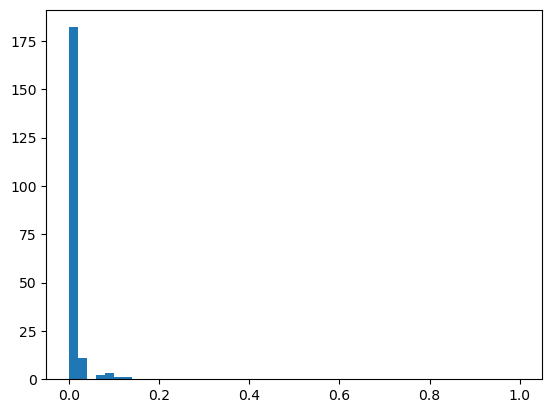

In [320]:
plt.hist(df['fsigpix'],bins=50,range=(0,1))

In [321]:
def plot(df,i,thresh = 0.8):
    tmp = df.iloc[i]
    im = np.histogram2d(tmp['xcam'],tmp['ycam'],weights=tmp['qcam'],bins=(512,288),range=((0,512),(0,288)))[0].T
    imNR = np.histogram2d(tmp['xcam'],tmp['ycam'],weights=tmp['qcam']*(1-tmp['ER_frac_cam']),bins=(512,288),range=((0,512),(0,288)))[0].T
    ys,xs = np.where(imNR > 100)
    NRxmin = xs.min()-5
    NRxmax = xs.max()+5
    NRymin = ys.min()-5
    NRymax = ys.max()+5
    plt.imshow(np.log10(im+1),cmap='turbo',vmin=2)
    #plt.imshow(im,cmap='turbo',vmin=100)
    plt.colorbar()
    plt.xlim(tmp['xcam'].min()-5,tmp['xcam'].max()+5)
    plt.ylim(tmp['ycam'].min()-5,tmp['ycam'].max()+5)
    idx = np.where((tmp['ER_frac_cam'] > thresh) & (tmp['qcam']>100))[0]
    plt.title(f"fsigpix = {np.round(len(idx)/len(np.where((tmp['ER_frac_cam'] > 0) & (tmp['qcam']>100))[0]),2)}")
    xmin = tmp['xcam'][idx].min()-1
    xmax = tmp['xcam'][idx].max()+1
    ymin = tmp['ycam'][idx].min()-1
    ymax = tmp['ycam'][idx].max()+1
    plt.hlines(ymin,xmin,xmax,lw=2,color='w')
    plt.hlines(ymax,xmin,xmax,lw=2,color='w')
    plt.vlines(xmin,ymin,ymax,lw=2,color='w')
    plt.vlines(xmax,ymin,ymax,lw=2,color='w')
    plt.hlines(NRymin,NRxmin,NRxmax,lw=2,color='r')
    plt.hlines(NRymax,NRxmin,NRxmax,lw=2,color='r')
    plt.vlines(NRxmin,NRymin,NRymax,lw=2,color='r')
    plt.vlines(NRxmax,NRymin,NRymax,lw=2,color='r') 
    #plt.plot(tmp['xcam'][idx],tmp['ycam'][idx],'o',color='w')
    #plt.show()

IndexError: single positional indexer is out-of-bounds

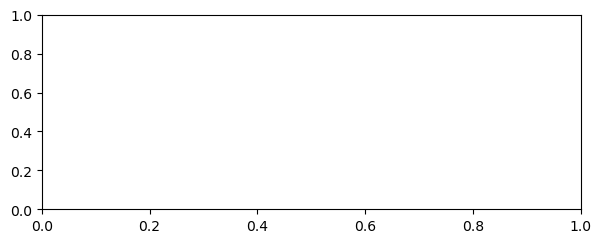

In [322]:
plt.figure(figsize = (32,48))
for i in range(0,64):
    plt.subplot(16,4,i+1)
    plot(df.query('fsigpix>0.15'),i)

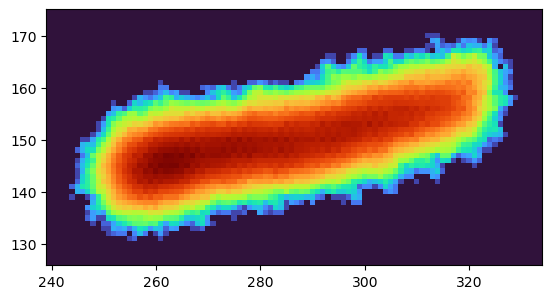

In [66]:
plot(df,50)